In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [42]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
from pathlib import Path
import sys
import pandas as pd
import corner

import cogwheel.likelihood
import cogwheel.data
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, get_bayes_factor_of_samples
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, add_derived_quantities

In [3]:
# helper function to get median values
def get_medians(samples, corner_plot):
    medians = {}
    for key in samples.keys():
        medians[key] = corner_plot._get_median_and_central_interval(key)[0]
    return medians

In [4]:
# load samples from event posterior(s)

# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 2 events


In [5]:
# load the samples from one event posterior
idx = 0
eventname = eventname_list[idx]

# find the "earliest" run with posterior samples
i = 0
while i < 10:
    try:
        samples = pd.read_feather(os.path.join(event_dir_list[idx], f'run_{i}', 'samples.feather'))
        print(f"loaded posterior samples for {eventname} run {i}")
        break
    except FileNotFoundError:
        i += 1

# add derived quantities
add_derived_quantities(samples)

loaded posterior samples for GW230628_231200 run 1


In [6]:
# load the posterior samples from the LIGO PE data release
pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
data = read(pe_data_fn)
# get the posterior samples using the IMRPhenomXPHM approximant
posterior_samples_dr = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]

2025-12-30  20:34:08 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2025-12-30  20:34:08 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.


In [7]:
samples.keys()

Index(['mchirp', 'lnq', 'cums1z', 'cums2z', 'folded_costheta_jn', 'phi_jl_hat',
       'phi12', 'cums1r_s1z', 'cums2r_s2z', 'weights', 'f_ref', 'm1', 'm2',
       's1z', 's2z', 'iota', 's1x_n', 's1y_n', 's2x_n', 's2y_n', 'l1', 'l2',
       'd_luminosity', 'dec', 'lon', 'phi_ref', 'psi', 't_geocenter',
       'lnl_marginalized', 'lnl', 'h_h', 'n_effective', 'n_qmc', 'p_lensed',
       'ra', 'redshift', 'mtot', 'm1_source', 'm2_source', 'mtot_source',
       'chieff', 'q'],
      dtype='object')

In [8]:
# plot parameters for our cogwheel results:
plot_params = [
    'mchirp',
    'm1',
    'm2',
    'chieff',
    'd_luminosity',
    'ra',
    'dec',
    'p_lensed'
]

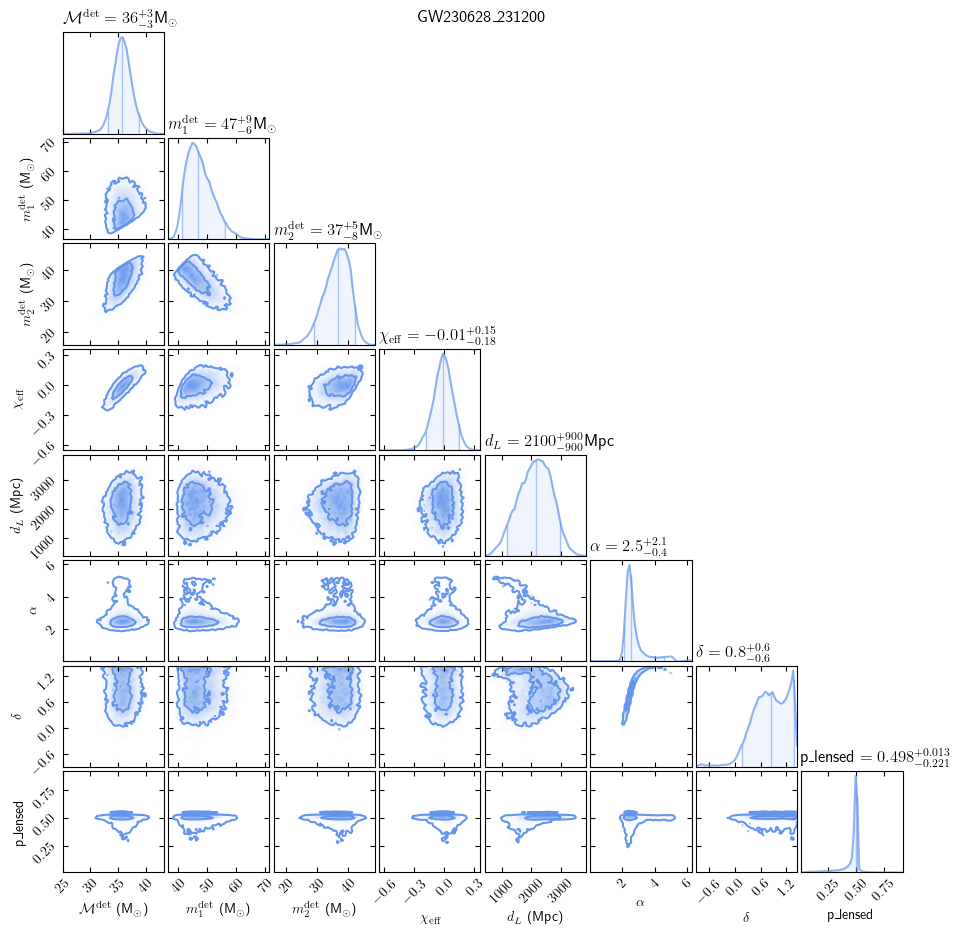

In [9]:
# Note: cogwheel.gw_plotting.CornerPlot understands the weights automatically
corner_plot = cogwheel.gw_plotting.CornerPlot(
    samples, params=plot_params, tail_probability=1e-4, color_2d='cornflowerblue',
    kwargs_1d=dict(color='cornflowerblue', alpha=0.7)
)
corner_plot.plot(title=eventname)

In [27]:
cp.latex_labels['p_lensed']

'p_lensed'

Text(0.5, 1.0, 'GW230628_231200: p_lensed${}={}$$0.498_{-0.221}^{+0.013}$')

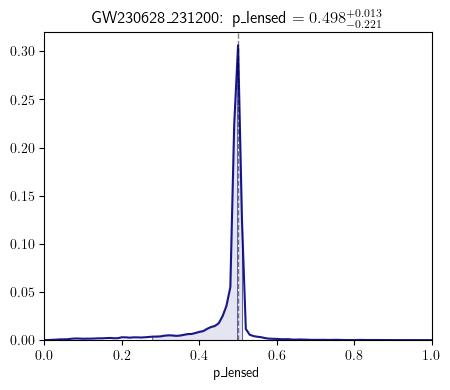

In [38]:
cp = cogwheel.gw_plotting.CornerPlot(
    samples, params=['p_lensed'], tail_probability=1e-4
)
hist, edges = np.histogram(samples['p_lensed'], bins=100,
                           weights=samples['weights'])
# we want the pdf at edges, not midpoints:
pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(edges, pdf, c='navy', alpha=0.9)
ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
ax.set_xlabel('p_lensed')
ax.set_xlim(0., 1.)
ax.set_ylim(0., 0.32)

# vlines
median, *span = cp._get_median_and_central_interval('p_lensed')
for val in (median, *span):
    ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
idx = (edges > span[0]) & (edges < span[1])
ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)
ax.set_title(eventname)
ax.set_title((f"{eventname}: p_lensed" + '${}={}$'
                          + latex_val_err(median, np.subtract(median, span))))

In [37]:
get_bayes_factor_p_lensed(samples)

np.float64(0.8808523100791172)

#### bootstrap

In [39]:
from scipy.stats import bootstrap

Text(0.5, 1.0, 'p_lensed resampling')

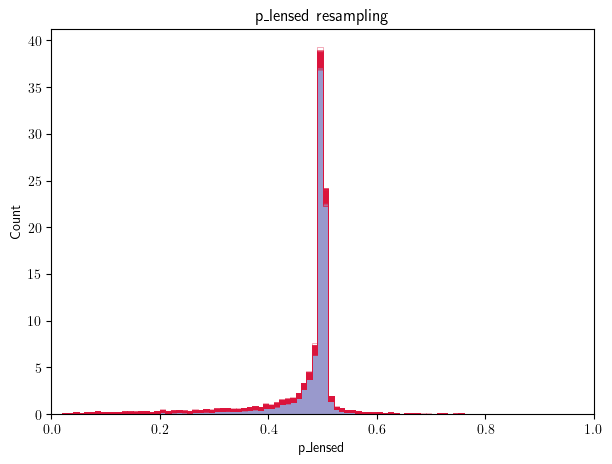

In [83]:
fig, ax = plt.subplots(figsize=(7,5))

n_resamples = 1000
bayes_factors = []

bins = 100
_, bins, _ = ax.hist(samples['p_lensed'],
                     bins=bins,
                     weights=samples['weights'],
                     density=True,  # density True to plot the PDF
                     histtype='stepfilled', color='navy', alpha=0.4)

for i in range(n_resamples):
    # shuffle the indices
    idx = np.random.choice(len(samples), size=len(samples), replace=True)
    resampled_p_lensed, reweights = samples['p_lensed'][idx], samples['weights'][idx]
        # remember we also have to shuffle the weights in the same way

    hist, edges = np.histogram(resampled_p_lensed, bins=bins, weights=reweights, density=True)

    ax.step(edges[:-1], hist, where='post', alpha=0.5, lw=0.5, color='crimson')

    # get the bayes factor of the resampled distribution:
    bayes_factors.append(bayes_factor_p_lensed(resampled_p_lensed, weights=reweights))

ax.set_xlim(0., 1.)
ax.set_xlabel('p_lensed')
ax.set_ylabel('Count')
ax.set_title('p_lensed resampling')

Text(0.5, 1.0, 'Bayes factor bootstrap: 1000 resamples: $\\mathcal{B}=$0.881$\\pm$0.002')

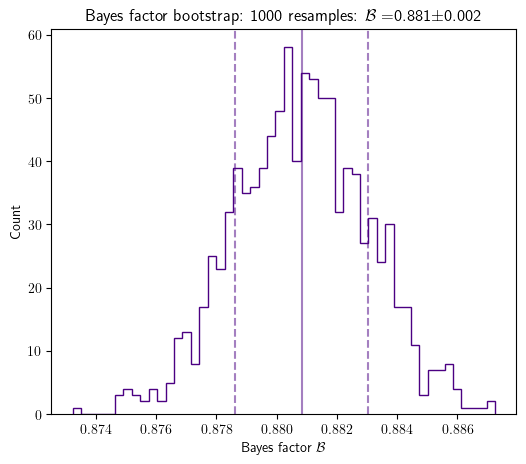

In [95]:
# Bayes factor distribution
c = 'indigo'
fig, ax = plt.subplots(figsize=(6,5))
_, _, _ = ax.hist(bayes_factors, bins=50, histtype='step', color=c)
median, std = np.median(bayes_factors), np.std(bayes_factors)
ax.axvline(median, c=c, alpha=0.5)
for x in [median + std, median - std]:
    ax.axvline(x, c=c, alpha=0.5, ls='--')
ax.set_xlabel(r'Bayes factor $\mathcal{B}$')
ax.set_ylabel('Count')
ax.set_title(f'Bayes factor bootstrap: {n_resamples} resamples: 'r'$\mathcal{B}=$'f'{median:.3f}'r'$\pm$'f'{std:.3f}')